<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Summer-School-2026/blob/main/Agentic_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🛠️ Applied LLMs

So far we *built* and *trained* models. In the real world, you'll mostly *use* models through an API. This section: **prompting → structured outputs → RAG → agents.**

## 📡 Step 1: Anatomy of an API call

Every LLM API call has the same skeleton, regardless of provider (OpenAI, Anthropic, Google):

- **model** — which LLM to use
- **system instruction** — who the model *is* (persona, rules, constraints)
- **messages/contents** — the conversation (user & model turns)
- **generation config** — temperature, max tokens, etc.

> 🔑 Get a free API key at [aistudio.google.com/apikey](https://aistudio.google.com/apikey) — then add it in Colab's 🔑 Secrets panel (left sidebar) as `GOOGLE_API_KEY`.

In [ ]:
!pip install -q google-genai

In [ ]:
from google import genai
from google.genai import types
from google.colab import userdata

# Read key from Colab Secrets (never hardcode keys in notebooks!)
client = genai.Client(api_key=userdata.get('GEMINI_API_KEY'))

MODEL = "gemini-2.5-flash"

# The full anatomy of a prompt
response = client.models.generate_content(
    model=MODEL,
    config=types.GenerateContentConfig(
        system_instruction=(
            "You are a teaching assistant at an AI summer school. "
            "Answer in exactly 2 sentences, simple language."
        ),
        temperature=0.7,
        max_output_tokens=1000,
    ),
    contents="Why did decoder-only models like GPT win over encoder-only models like BERT?"
)

print(response.text)

Decoder-only models like GPT are designed to generate text sequentially, predicting the next word in a sentence. This capability makes them incredibly powerful for creating new content, like chatbots and creative writing, which became a highly demanded feature in AI.


## 📦 Step 2: Structured Outputs — from chat to software

Free text is nice for humans, useless for code. You can't `if` on a paragraph.

Modern APIs can **force the model's output to match a schema** — the model doesn't just *try* to produce JSON, the API *guarantees* valid JSON matching your types. This is the bridge between "LLM as chatbot" and "LLM as a component in a real system."

We define the schema with **Pydantic** and get back parsed Python objects.

In [ ]:
from pydantic import BaseModel
from typing import Literal

# ---- Define the shape we want, as plain Python classes ----
class SessionInfo(BaseModel):
    speaker: str
    topic: str
    difficulty: Literal["beginner", "intermediate", "advanced"]
    prerequisites: list[str]
    duration_minutes: int

# ---- Unstructured, messy input text ----
messy_text = """
Hey! So tomorrow afternoon Prof. Ashutosh Modi is doing this deep-dive
on RLHF, DPO and alignment. Runs for an hour and a half.
Honestly it's pretty advanced material — you should know basic
transformers, and ideally have seen supervised fine-tuning before.
"""

response = client.models.generate_content(
    model=MODEL,
    config=types.GenerateContentConfig(
        response_mime_type="application/json",
        response_schema=SessionInfo,        # <- the magic line
    ),
    contents=f"Extract the session details from this text:\n{messy_text}"
)

# Not a string — a validated Python object!
session: SessionInfo = response.parsed
print(f"Speaker:       {session.speaker}")
print(f"Topic:         {session.topic}")
print(f"Difficulty:    {session.difficulty}")
print(f"Prereqs:       {session.prerequisites}")
print(f"Duration:      {session.duration_minutes} min")
print(f"\nType of result: {type(session)}")

Speaker:       Prof. Ashutosh Modi
Topic:         RLHF, DPO and alignment stuff
Difficulty:    advanced
Prereqs:       ['basic transformers', 'supervised fine-tuning']
Duration:      90 min

Type of result: <class '__main__.SessionInfo'>


## 📚 Step 3: RAG — Retrieval-Augmented Generation

### The problem

LLMs have two fatal knowledge gaps:

<div style="display:flex; gap:20px; justify-content:center; margin:16px 0; text-align:center;">
  <div style="border:2px solid #d95a5a; border-radius:10px; padding:12px 18px; width:260px;">
    🧊 <b>Frozen knowledge</b><br>
    <span style="font-size:13px;">Training ended months ago. Ask about yesterday → it has no idea (but may answer anyway 😬)</span>
  </div>
  <div style="border:2px solid #d95a5a; border-radius:10px; padding:12px 18px; width:260px;">
    🔒 <b>No private data</b><br>
    <span style="font-size:13px;">Your company wiki, your PDFs, this summer school's schedule — never seen any of it</span>
  </div>
</div>

Fine-tuning on your data? Expensive, slow, and needs redoing every time data changes.

**RAG's idea is simpler:** don't put knowledge *in the weights* — put it *in the prompt*. Find the relevant documents at question-time and paste them into the context. The LLM becomes an **open-book exam** instead of a closed-book one. 📖

### The pipeline

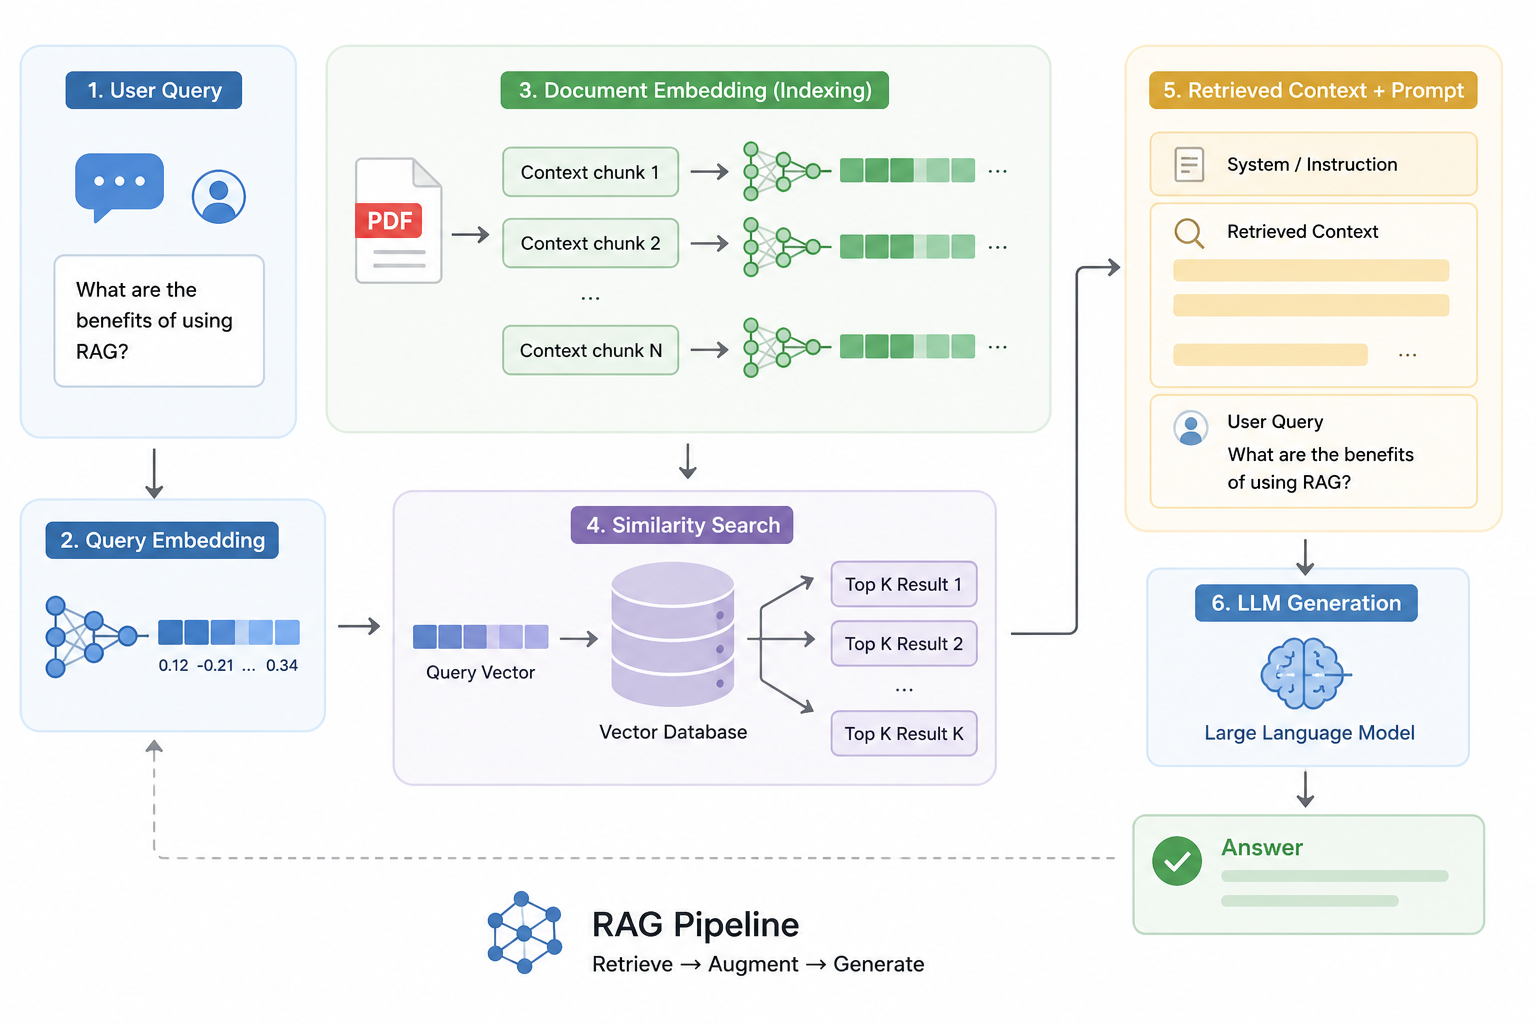

<div style="font-family:monospace; text-align:center; margin:18px 0; line-height:2.2;">
<span style="border:2px solid #d9c15a; border-radius:8px; padding:6px 12px;">📄 Documents</span> ➡️
<span style="border:2px solid #d9c15a; border-radius:8px; padding:6px 12px;">✂️ Chunks</span> ➡️
<span style="border:2px solid #d9c15a; border-radius:8px; padding:6px 12px;">🔢 Embeddings</span> ➡️
<span style="border:2px solid #d9c15a; border-radius:8px; padding:6px 12px;">🗄️ Vector store</span>
<br>
<span style="font-size:13px; color:#888;">⬆️ INDEXING — done once, offline</span>
<br><br>
<span style="border:2px solid #5ad98f; border-radius:8px; padding:6px 12px;">❓ Question</span> ➡️
<span style="border:2px solid #5ad98f; border-radius:8px; padding:6px 12px;">🔢 Embed it</span> ➡️
<span style="border:2px solid #5ad98f; border-radius:8px; padding:6px 12px;">🔍 Top-k similar chunks</span> ➡️
<span style="border:2px solid #5ad98f; border-radius:8px; padding:6px 12px;">🧠 LLM + chunks</span> ➡️
<span style="border:2px solid #5ad98f; border-radius:8px; padding:6px 12px;">✅ Grounded answer</span>
<br>
<span style="font-size:13px; color:#888;">⬆️ RETRIEVAL — every query, milliseconds</span>
</div>

### The key trick: embeddings 🔢

An **embedding model** turns any text into a vector (list of numbers) where **similar meaning → nearby vectors**:

<div style="font-family:monospace; text-align:center; margin:14px 0; font-size:14px;">
"How do I reset my password?" → <span style="color:#5ad98f;">[0.21, -0.83, 0.55, …]</span><br>
"Steps to recover my account&nbsp;" → <span style="color:#5ad98f;">[0.19, -0.79, 0.58, …]</span> ← <b>close!</b> 📏<br>
"Best biryani in Hyderabad&nbsp;&nbsp;&nbsp;" → <span style="color:#d95a5a;">[-0.67, 0.12, -0.91, …]</span> ← far away
</div>

Search happens by **vector distance, not keywords** — a question about "recovering my account" finds the "password reset" doc even though they share zero words. That's semantic search, and it's the engine under every RAG system.

> 🎯 **One-liner to remember:** *RAG = semantic search + paste results into the prompt.* Everything else is optimization.

In [ ]:
import numpy as np

# ---------- Internal knowledge base of a fictional company ----------
# Think: HR policies, IT docs, product info — data no public LLM has ever seen.
documents = [
    "Acme Corp employees are entitled to 24 days of paid annual leave. Unused leave up to 5 days can be carried into the next calendar year.",
    "To request a laptop replacement, employees must raise a ticket in the IT portal under 'Hardware > Refresh'. Standard replacement cycle is 3 years.",
    "Acme Corp's remote work policy allows up to 3 days per week of remote work, subject to manager approval. Fully remote arrangements require VP sign-off.",
    "Expense claims must be submitted within 30 days of purchase. Claims above USD 500 require pre-approval from the department head.",
    "The corporate VPN can be accessed via the GlobalConnect client. First-time setup requires enrolling your device in the MDM system.",
    "Acme Corp's flagship product, FlowSuite, offers three pricing tiers: Starter (USD 29/user/month), Professional (USD 79/user/month), and Enterprise (custom pricing).",
    "Customer support for FlowSuite Enterprise customers is available 24/7 with a guaranteed 1-hour response SLA. Starter and Professional tiers have a 24-hour SLA.",
    "New employees must complete security awareness training within 14 days of joining. Non-completion results in suspension of system access.",
]

In [ ]:
# ---------- INDEXING: embed every document (done once) ----------
def embed(texts, task_type):
    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=texts,
        config=types.EmbedContentConfig(task_type=task_type),
    )
    return np.array([e.values for e in result.embeddings])

doc_vectors = embed(documents, task_type="RETRIEVAL_DOCUMENT")
print(f"Indexed {len(documents)} docs → vectors of dimension {doc_vectors.shape[1]}")

# ---------- RETRIEVAL: find top-k chunks by cosine similarity ----------
def retrieve(query, k=2):
    q_vec = embed([query], task_type="RETRIEVAL_QUERY")[0]
    # cosine similarity = dot product of normalized vectors
    sims = doc_vectors @ q_vec / (np.linalg.norm(doc_vectors, axis=1) * np.linalg.norm(q_vec))
    top_idx = np.argsort(sims)[::-1][:k]
    return [(documents[i], sims[i]) for i in top_idx]

# ---------- GENERATION: answer using ONLY retrieved context ----------
def rag_answer(query):
    hits = retrieve(query)
    context = "\n".join(f"- {doc}" for doc, _ in hits)
    prompt = f"""You are an internal assistant for Acme Corp employees.
Answer the question using ONLY the context below.
If the answer is not in the context, say "I don't have that information."

Context:
{context}

Question: {query}"""
    response = client.models.generate_content(model=MODEL, contents=prompt)

    print(f"❓ {query}")
    print(f"\n🔍 Retrieved:")
    for doc, score in hits:
        print(f"   [{score:.3f}] {doc}")
    print(f"\n✅ {response.text}")
    print("=" * 70)

Indexed 8 docs → vectors of dimension 3072


In [ ]:
rag_answer("How many vacation days do I get, and can I carry them over?")

❓ How many vacation days do I get, and can I carry them over?

🔍 Retrieved:
   [0.753] Acme Corp employees are entitled to 24 days of paid annual leave. Unused leave up to 5 days can be carried into the next calendar year.
   [0.625] Acme Corp's remote work policy allows up to 3 days per week of remote work, subject to manager approval. Fully remote arrangements require VP sign-off.

✅ Acme Corp employees are entitled to 24 days of paid annual leave. You can carry over up to 5 unused days into the next calendar year.


In [ ]:
rag_answer("My laptop is broken, what do I do?")

❓ My laptop is broken, what do I do?

🔍 Retrieved:
   [0.682] To request a laptop replacement, employees must raise a ticket in the IT portal under 'Hardware > Refresh'. Standard replacement cycle is 3 years.
   [0.588] The corporate VPN can be accessed via the GlobalConnect client. First-time setup requires enrolling your device in the MDM system.

✅ To request a laptop replacement, you must raise a ticket in the IT portal under 'Hardware > Refresh'.


In [ ]:
rag_answer("How fast will support respond for an Enterprise customer?")

❓ How fast will support respond for an Enterprise customer?

🔍 Retrieved:
   [0.795] Customer support for FlowSuite Enterprise customers is available 24/7 with a guaranteed 1-hour response SLA. Starter and Professional tiers have a 24-hour SLA.
   [0.624] Acme Corp's flagship product, FlowSuite, offers three pricing tiers: Starter (USD 29/user/month), Professional (USD 79/user/month), and Enterprise (custom pricing).

✅ Support will respond for an Enterprise customer with a guaranteed 1-hour response SLA.


### Vector DB

Recent RAG systems use a **vector database** (Chroma, FAISS, Pinecone, pgvector) that handles storage, indexing and fast search at millions of documents. And real knowledge lives in **files**, not Python lists.

So let's do it properly: **PDF → parse → chunk → embed → vector DB → query.**

### Make a pdf

In [ ]:
!pip install weasyprint
!pip install langchain_text_splitters

In [ ]:
from weasyprint import HTML

# 1. Define the HTML and CSS layout structured for print
html_content = """
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Acme Corp — Employee Handbook (Extract)</title>
<style>
    /* Configure page dimensions and margins */
    @page {
        size: A4;
        margin: 20mm 15mm 20mm 15mm;
        background-color: #ffffff;

        @bottom-right {
            content: counter(page);
            font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
            font-size: 9pt;
            color: #888888;
        }
        @bottom-left {
            content: "Acme Corp — Employee Handbook (Extract)";
            font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
            font-size: 9pt;
            color: #888888;
        }
    }

    *, *::before, *::after {
        box-sizing: border-box;
    }

    body {
        margin: 0;
        padding: 0;
        font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif;
        color: #333333;
        line-height: 1.6;
        font-size: 10.5pt;
    }

    /* Header styling styling */
    .header-container {
        border-bottom: 2px solid #1a365d;
        padding-bottom: 15px;
        margin-bottom: 30px;
    }

    h1 {
        color: #1a365d;
        font-size: 22pt;
        margin: 0 0 5px 0;
        font-weight: 700;
        letter-spacing: -0.5px;
    }

    .subtitle {
        color: #4a5568;
        font-size: 12pt;
        margin: 0;
        text-transform: uppercase;
        letter-spacing: 1px;
        font-weight: 600;
    }

    /* Document Section formatting */
    .policy-section {
        margin-bottom: 25px;
        page-break-inside: avoid; /* Prevents an individual section splitting over pages */
    }

    h2 {
        color: #2b6cb0;
        font-size: 14pt;
        margin: 0 0 8px 0;
        font-weight: 600;
        border-left: 4px solid #2b6cb0;
        padding-left: 10px;
        page-break-after: avoid; /* Prevents orphaned headers at bottom of page */
    }

    p {
        margin: 0 0 10px 0;
        text-align: justify;
    }

    /* Structured Table layout for SLA information */
    table {
        width: 100%;
        border-collapse: collapse;
        margin-top: 12px;
        font-size: 10pt;
    }

    th, td {
        border: 1px solid #e2e8f0;
        padding: 8px 12px;
        text-align: left;
    }

    th {
        background-color: #ebf8ff;
        color: #2b6cb0;
        font-weight: 600;
    }

    tr:nth-child(even) {
        background-color: #f7fafc;
    }
</style>
</head>
<body>

    <div class="header-container">
        <h1>Acme Corp</h1>
        <div class="subtitle">Employee Handbook (Extract)</div>
    </div>

    <div class="policy-section">
        <h2>1. Leave Policy</h2>
        <p>Employees are entitled to 24 days of paid annual leave per calendar year. Unused leave up to a maximum of 5 days may be carried over into the next calendar year. Carry-over requests must be submitted before December 15.</p>
    </div>

    <div class="policy-section">
        <h2>2. Remote Work</h2>
        <p>Employees may work remotely up to 3 days per week, subject to manager approval. Fully remote arrangements require sign-off from a Vice President and are reviewed every 6 months.</p>
    </div>

    <div class="policy-section">
        <h2>3. IT Equipment</h2>
        <p>Laptop replacements follow a standard 3-year refresh cycle. For a broken or malfunctioning device, raise a ticket in the IT portal under <strong>Hardware &gt; Refresh</strong>. Loaner devices are available within 24 hours.</p>
    </div>

    <div class="policy-section">
        <h2>4. Expenses</h2>
        <p>Expense claims must be submitted within 30 days of purchase. Any claim above <strong>USD 500</strong> requires written pre-approval from the department head. Claims are reimbursed with the next payroll cycle.</p>
    </div>

    <div class="policy-section">
        <h2>5. Security Training</h2>
        <p>All new employees must complete security awareness training within 14 days of joining. Failure to complete training results in suspension of system access until the course is finished.</p>
    </div>

    <div class="policy-section">
        <h2>6. Product Support SLAs</h2>
        <p>Support response times are governed by customer subscription tiers as detailed below:</p>
        <table>
            <thead>
                <tr>
                    <th>Customer Tier</th>
                    <th>Support Coverage</th>
                    <th>First-Response SLA</th>
                </tr>
            </thead>
            <tbody>
                <tr>
                    <td><strong>FlowSuite Enterprise</strong></td>
                    <td>24/7 Coverage</td>
                    <td>1 Hour (Guaranteed)</td>
                </tr>
                <tr>
                    <td><strong>Professional</strong></td>
                    <td>Business Hours</td>
                    <td>24 Hours</td>
                </tr>
                <tr>
                    <td><strong>Starter</strong></td>
                    <td>Business Hours</td>
                    <td>24 Hours</td>
                </tr>
            </tbody>
        </table>
    </div>

</body>
</html>
"""

# 2. Write the string to a temporary HTML file
html_filename = "employee_handbook.html"
with open(html_filename, "w", encoding="utf-8") as f:
    f.write(html_content)

# 3. Use WeasyPrint to compile the file to PDF
pdf_filename = "employee_handbook.pdf"
HTML(html_filename).write_pdf(pdf_filename)

print(f"Success! Generated '{pdf_filename}' natively using HTML-to-PDF layout rules.")

Success! Generated 'employee_handbook.pdf' natively using HTML-to-PDF layout rules.


### Use the vector DB

In [ ]:
import chromadb
from pypdf import PdfReader
from langchain_text_splitters import RecursiveCharacterTextSplitter


# ---------- 1. PARSE: extract text from the PDF ----------
reader = PdfReader("/content/employee_handbook.pdf")
full_text = "\n".join(page.extract_text() for page in reader.pages)
print(f"Extracted {len(full_text)} characters from {len(reader.pages)} page(s)")

# ---------- 2. CHUNK: recursive character splitting ----------
# Tries to split on paragraphs first, then lines, then words — only
# falling back to raw characters if it must. Keeps semantic units intact.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,        # target size (characters)
    chunk_overlap=50,      # overlap so no fact is cut in half at a boundary
    separators=["\n\n", "\n", ". ", " ", ""],   # try in this order
)
chunks = splitter.split_text(full_text)
print(f"Split into {len(chunks)} chunks")
print(f"Example chunk:\n---\n{chunks[1]}\n---")

Extracted 1436 characters from 1 page(s)
Split into 7 chunks
Example chunk:
---
December 15.
2. Remote Work
Employees  may  work  remotely  up  to  3  days  per  week,  subject  to  manager  approval.  Fully  remote
arrangements require sign-off from a Vice President and are reviewed every 6 months.
3. IT Equipment
---


In [ ]:
# ---------- 3. EMBED + INDEX into ChromaDB ----------
def embed(texts, task_type):
    result = client.models.embed_content(
        model="gemini-embedding-001",
        contents=texts,
        config=types.EmbedContentConfig(task_type=task_type),
    )
    return [e.values for e in result.embeddings]

chroma = chromadb.Client()
collection = chroma.create_collection("acme_handbook")
collection.add(
    ids=[f"chunk_{i}" for i in range(len(chunks))],
    documents=chunks,
    embeddings=embed(chunks, "RETRIEVAL_DOCUMENT"),
)
print(f"Indexed {collection.count()} chunks into ChromaDB")

Indexed 7 chunks into ChromaDB


In [ ]:
# ---------- 4. RETRIEVE + GENERATE ----------
def rag_answer(query, k=2):
    q_emb = embed([query], "RETRIEVAL_QUERY")
    hits = collection.query(query_embeddings=q_emb, n_results=k)
    retrieved = hits["documents"][0]

    context = "\n\n".join(retrieved)
    prompt = f"""You are an internal assistant for Acme Corp employees.
Answer using ONLY the context below.
If the answer is not in the context, say "I don't have that information."

Context:
{context}

Question: {query}"""
    response = client.models.generate_content(model=MODEL, contents=prompt)

    print(f"❓ {query}")
    print(f"🔍 Retrieved {len(retrieved)} chunks "
          f"(distances: {[round(d, 3) for d in hits['distances'][0]]})")
    print(f"✅ {response.text}")
    print("=" * 70)

In [ ]:
rag_answer("Can I carry over unused vacation days? What's the deadline?")

❓ Can I carry over unused vacation days? What's the deadline?
🔍 Retrieved 2 chunks (distances: [0.663, 0.71])
✅ Yes, you may carry over unused leave up to a maximum of 5 days into the next calendar year. Carry-over requests must be submitted before December 15.


In [ ]:
rag_answer("What is the capital of France?")   # not in the handbook -> refuses

❓ What is the capital of France?
🔍 Retrieved 2 chunks (distances: [0.875, 0.886])
✅ I don't have that information.


## 🤖 Step 4: Agentic AI — LLMs that *act*

### From pipelines to agents

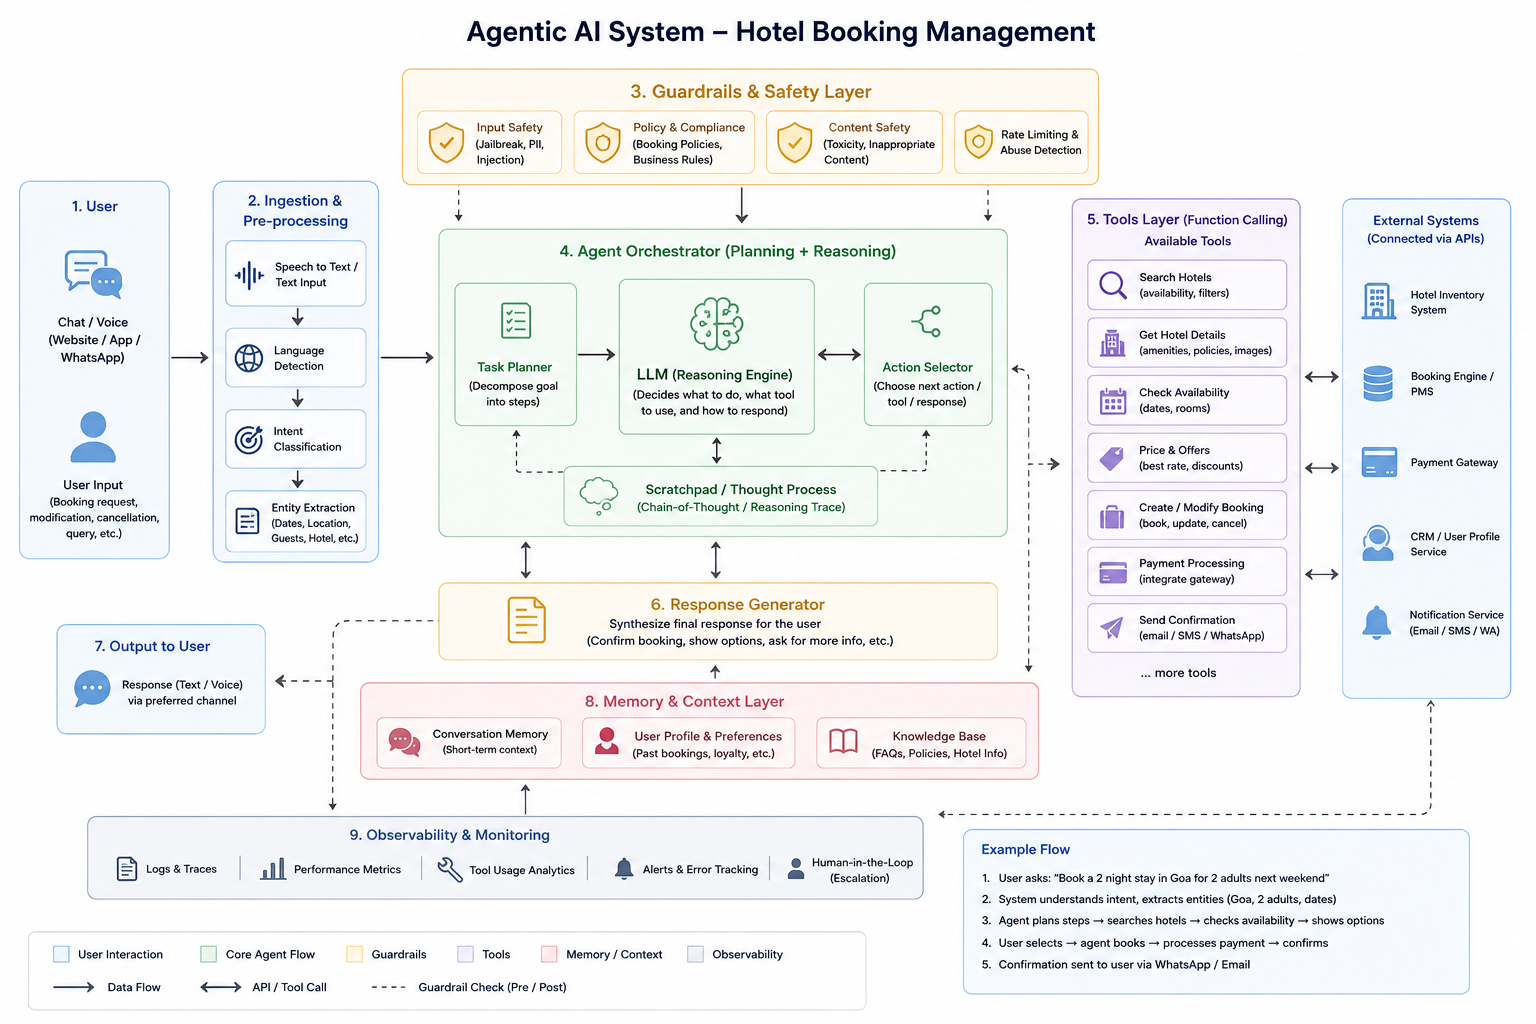

Everything so far follows a **fixed path we wrote**: prompt → (retrieve) → answer. Same steps, every time.

An **agent** flips this: we give the LLM a **goal** and a **toolbox**, and *it decides* which tools to call, in what order, and when it's done.

<div style="display:flex; gap:24px; justify-content:center; margin:16px 0; text-align:center;">
  <div style="border:2px solid #d9c15a; border-radius:10px; padding:12px 18px; width:270px;">
    ⛓️ <b>Pipeline (RAG)</b><br>
    <span style="font-size:13px;">Fixed flow, written by the developer.<br>Every query takes the same path.</span>
  </div>
  <div style="border:2px solid #5ad98f; border-radius:10px; padding:12px 18px; width:270px;">
    🤖 <b>Agent</b><br>
    <span style="font-size:13px;">Dynamic flow, decided by the LLM.<br>Loops: think → act → observe → repeat.</span>
  </div>
</div>

### The agent loop

<div style="font-family:monospace; text-align:center; margin:18px 0; line-height:2.4;">
<span style="border:2px solid #4a90d9; border-radius:8px; padding:6px 14px;">🧠 LLM thinks</span> ➡️
<span style="border:2px solid #4a90d9; border-radius:8px; padding:6px 14px;">🔧 calls a tool</span> ➡️
<span style="border:2px solid #4a90d9; border-radius:8px; padding:6px 14px;">👀 observes result</span>
<br>⬑ ————— <b>loops until the goal is met</b> ————— ⬏<br>
<span style="border:2px solid #5ad98f; border-radius:8px; padding:6px 14px;">✅ final answer</span>
</div>

**Tools** are just Python functions with good docstrings — the LLM reads the docstring to decide *when* to use each one. The model never executes anything itself; it outputs *"call this function with these arguments"* and **our code** runs it.

### What we'll build: a hotel booking agent 🏨

A customer-service agent for a hotel that can:
- 🔍 check room availability — *reads the database*
- 📝 create bookings — *writes to the database*
- 💸 process cancellations & refunds — *updates the database, with rules*

Built with **LangGraph**: the agent is a **graph** — nodes are steps (LLM call, tool execution), edges are the possible transitions. The loop above becomes literal nodes and edges we can draw.

### ⚠️ Guardrails — because this agent has real power

An agent that can write to your database and move money needs limits. We'll enforce:
1. **Business rules in code, not in the prompt** — e.g., refund eligibility is computed by the tool, the LLM can't "decide" to be generous. Prompts can be jailbroken; code cannot.
2. **Scoped tools** — the agent gets `cancel_booking()`, not `execute_sql()`. It can only do what its tools allow.
3. **Human-in-the-loop** — actions above a threshold (large refunds) get flagged for approval instead of auto-executing.

In [ ]:
import sqlite3
from datetime import date

conn = sqlite3.connect("hotel.db", check_same_thread=False)
cur = conn.cursor()

# ---------- Schema ----------
cur.executescript("""
DROP TABLE IF EXISTS rooms;
DROP TABLE IF EXISTS bookings;

CREATE TABLE rooms (
    room_id      INTEGER PRIMARY KEY,
    room_type    TEXT NOT NULL,          -- standard / deluxe / suite
    price_per_night REAL NOT NULL,
    is_available INTEGER NOT NULL DEFAULT 1
);

CREATE TABLE bookings (
    booking_id   INTEGER PRIMARY KEY AUTOINCREMENT,
    guest_name   TEXT NOT NULL,
    room_id      INTEGER NOT NULL,
    check_in     TEXT NOT NULL,
    check_out    TEXT NOT NULL,
    total_amount REAL NOT NULL,
    status       TEXT NOT NULL DEFAULT 'confirmed',   -- confirmed / cancelled
    refund_amount REAL DEFAULT 0,
    FOREIGN KEY (room_id) REFERENCES rooms(room_id)
);
""")

# ---------- Seed data ----------
rooms = [
    (101, "standard", 3500),
    (102, "standard", 3500),
    (201, "deluxe",   6000),
    (202, "deluxe",   6000),
    (301, "suite",   12000),
]
cur.executemany("INSERT INTO rooms (room_id, room_type, price_per_night) VALUES (?, ?, ?)", rooms)

# One existing booking so cancellation/refund can be demoed immediately
cur.execute("""
INSERT INTO bookings (guest_name, room_id, check_in, check_out, total_amount)
VALUES ('Rahul Verma', 201, '2026-07-20', '2026-07-23', 18000)
""")
cur.execute("UPDATE rooms SET is_available = 0 WHERE room_id = 201")
conn.commit()

In [ ]:
# ---------- Verify ----------
import pandas as pd
print("ROOMS:")
display(pd.read_sql("SELECT * FROM rooms", conn))
print("BOOKINGS:")
display(pd.read_sql("SELECT * FROM bookings", conn))

ROOMS:


,room_id,room_type,price_per_night,is_available
0,101,standard,3500.0,1
1,102,standard,3500.0,1
2,201,deluxe,6000.0,0
3,202,deluxe,6000.0,1
4,301,suite,12000.0,1


BOOKINGS:


,booking_id,guest_name,room_id,check_in,check_out,total_amount,status,refund_amount
0,1,Rahul Verma,201,2026-07-20,2026-07-23,18000.0,confirmed,0.0


In [ ]:
!pip install -q langchain langchain-google-genai langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 2.4 MB/s eta 0:00:00


In [ ]:
from langchain_core.tools import tool
from datetime import datetime

# ============================================================
# TOOL 1: Read-only — check what's available
# ============================================================
@tool
def check_availability(room_type: str = "any") -> str:
    """Check which hotel rooms are currently available.
    Args:
        room_type: 'standard', 'deluxe', 'suite', or 'any'.
    Returns a list of available rooms with prices per night (INR)."""
    q = "SELECT room_id, room_type, price_per_night FROM rooms WHERE is_available = 1"
    params = ()
    if room_type != "any":
        q += " AND room_type = ?"
        params = (room_type,)
    rows = cur.execute(q, params).fetchall()
    if not rows:
        return f"No {room_type} rooms available."
    return "\n".join(f"Room {r[0]} ({r[1]}): ₹{r[2]:.0f}/night" for r in rows)

# ============================================================
# TOOL 2: Write — create a booking
# ============================================================
@tool
def create_booking(guest_name: str, room_id: int, check_in: str, check_out: str) -> str:
    """Book a room for a guest.
    Args:
        guest_name: full name of the guest.
        room_id: the room number to book.
        check_in: check-in date, format YYYY-MM-DD.
        check_out: check-out date, format YYYY-MM-DD.
    Returns booking confirmation with booking ID and total amount."""
    row = cur.execute(
        "SELECT price_per_night, is_available FROM rooms WHERE room_id = ?", (room_id,)
    ).fetchone()

    # --- Guardrails: validate BEFORE touching state ---
    if row is None:
        return f"Error: room {room_id} does not exist."
    price, available = row
    if not available:
        return f"Error: room {room_id} is not available."
    try:
        d_in = datetime.strptime(check_in, "%Y-%m-%d").date()
        d_out = datetime.strptime(check_out, "%Y-%m-%d").date()
    except ValueError:
        return "Error: dates must be YYYY-MM-DD."
    nights = (d_out - d_in).days
    if nights <= 0:
        return "Error: check-out must be after check-in."
    if d_in < date.today():
        return "Error: check-in date is in the past."

    total = nights * price
    cur.execute(
        """INSERT INTO bookings (guest_name, room_id, check_in, check_out, total_amount)
           VALUES (?, ?, ?, ?, ?)""",
        (guest_name, room_id, check_in, check_out, total),
    )
    cur.execute("UPDATE rooms SET is_available = 0 WHERE room_id = ?", (room_id,))
    conn.commit()
    return (f"Booking confirmed! ID: {cur.lastrowid}, {guest_name}, room {room_id}, "
            f"{check_in} to {check_out} ({nights} nights), total ₹{total:.0f}.")

# ============================================================
# TOOL 3: Sensitive — cancel & refund (policy enforced in CODE)
# ============================================================
APPROVAL_THRESHOLD = 10000  # refunds above this need a human

@tool
def cancel_and_refund(booking_id: int) -> str:
    """Cancel a booking and process the refund according to hotel policy.
    Refund policy: >7 days before check-in = 100%, 3-7 days = 50%, <3 days = 0%.
    Args:
        booking_id: the ID of the booking to cancel.
    Returns cancellation status and refund amount."""
    row = cur.execute(
        "SELECT guest_name, room_id, check_in, total_amount, status FROM bookings WHERE booking_id = ?",
        (booking_id,),
    ).fetchone()
    if row is None:
        return f"Error: booking {booking_id} not found."
    guest, room_id, check_in, total, status = row
    if status == "cancelled":
        return f"Error: booking {booking_id} is already cancelled."

    # --- Guardrail 1: refund % computed by CODE, not by the LLM ---
    days_until = (datetime.strptime(check_in, "%Y-%m-%d").date() - date.today()).days
    pct = 1.0 if days_until > 7 else (0.5 if days_until >= 3 else 0.0)
    refund = total * pct

    # --- Guardrail 3: human-in-the-loop for large refunds ---
    if refund > APPROVAL_THRESHOLD:
        return (f"PENDING APPROVAL: refund of ₹{refund:.0f} for booking {booking_id} "
                f"exceeds the ₹{APPROVAL_THRESHOLD} auto-approval limit. "
                f"A manager has been notified; the guest will be contacted within 24h.")

    cur.execute(
        "UPDATE bookings SET status = 'cancelled', refund_amount = ? WHERE booking_id = ?",
        (refund, booking_id),
    )
    cur.execute("UPDATE rooms SET is_available = 1 WHERE room_id = ?", (room_id,))
    conn.commit()
    return (f"Booking {booking_id} cancelled for {guest}. "
            f"{days_until} days before check-in → {pct:.0%} refund policy → ₹{refund:.0f} refunded.")


In [ ]:
tools = [check_availability, create_booking, cancel_and_refund]
print("Tools ready:", [t.name for t in tools])

# Quick sanity check — call one directly, no LLM involved yet:
print("\n" + check_availability.invoke({"room_type": "any"}))

Tools ready: ['check_availability', 'create_booking', 'cancel_and_refund']

Room 101 (standard): ₹3500/night
Room 102 (standard): ₹3500/night
Room 202 (deluxe): ₹6000/night
Room 301 (suite): ₹12000/night


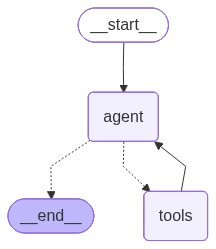

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from google.colab import userdata
from IPython.display import Image, display

# ---------- The LLM, with tools bound ----------
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=userdata.get("GEMINI_API_KEY"),
    temperature=0,          # agents should be deterministic, not creative
)
llm_with_tools = llm.bind_tools(tools)

SYSTEM_PROMPT = """You are the booking assistant for Acme Grand Hotel.
Help guests check availability, make bookings, and process cancellations.
Always confirm details (name, room, dates) before creating a booking.
Be concise and professional. Use the tools for any real information or
action — never invent room numbers, prices, or booking IDs."""

# ---------- Node 1: the agent (LLM decides) ----------
def agent_node(state: MessagesState):
    messages = [SystemMessage(SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

# ---------- Node 2: tool executor (runs what the LLM asked for) ----------
tool_node = ToolNode(tools)

# ---------- The conditional edge: loop or finish? ----------
def should_continue(state: MessagesState):
    last = state["messages"][-1]
    if last.tool_calls:        # LLM asked for a tool -> go execute it
        return "tools"
    return END                 # no tool call -> LLM gave its final answer

# ---------- Assemble the graph ----------
builder = StateGraph(MessagesState)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "agent")                     # entry: user msg -> agent
builder.add_conditional_edges("agent", should_continue, ["tools", END])
builder.add_edge("tools", "agent")                   # tool result -> back to agent (THE LOOP)

memory = MemorySaver()                               # conversation memory
graph = builder.compile(checkpointer=memory)

# ---------- Draw the graph ----------
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "demo-guest-1"}}   # one conversation thread

def chat(user_message):
    print(f"\n{'='*70}\n🧑 GUEST: {user_message}\n{'-'*70}")
    events = graph.stream(
        {"messages": [HumanMessage(user_message)]},
        config,
        stream_mode="values",
    )
    for event in events:
        msg = event["messages"][-1]
        if msg.type == "ai" and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"🧠 AGENT decided → call {tc['name']}({tc['args']})")
        elif msg.type == "tool":
            print(f"🔧 TOOL returned  → {msg.content}")
        elif msg.type == "ai":
            print(f"🤖 AGENT: {msg.content}")

In [ ]:
# ---------------- THE DEMO ----------------
chat("Hi! Do you have any deluxe rooms available?")


🧑 GUEST: Hi! Do you have any deluxe rooms available?
----------------------------------------------------------------------
🧠 AGENT decided → call check_availability({'room_type': 'deluxe'})
🔧 TOOL returned  → Room 202 (deluxe): ₹6000/night
🤖 AGENT: Yes, we have one deluxe room available, Room 202, for ₹6000 per night.


In [ ]:
chat("Great, book room 202 for me — Priya Sharma, July 15th to 17th 2026.")


🧑 GUEST: Great, book room 202 for me — Priya Sharma, July 15th to 17th 2026.
----------------------------------------------------------------------
🧠 AGENT decided → call create_booking({'check_out': '2026-07-17', 'room_id': 202, 'guest_name': 'Priya Sharma', 'check_in': '2026-07-15'})
🔧 TOOL returned  → Booking confirmed! ID: 2, Priya Sharma, room 202, 2026-07-15 to 2026-07-17 (2 nights), total ₹12000.
🤖 AGENT: Booking confirmed! ID: 2, Priya Sharma, room 202, July 15th to 17th 2026 (2 nights), total ₹12000.


In [ ]:
chat("Actually my plans changed. Please cancel that booking.")


🧑 GUEST: Actually my plans changed. Please cancel that booking.
----------------------------------------------------------------------
🧠 AGENT decided → call cancel_and_refund({'booking_id': 2})
🔧 TOOL returned  → PENDING APPROVAL: refund of ₹12000 for booking 2 exceeds the ₹10000 auto-approval limit. A manager has been notified; the guest will be contacted within 24h.
🤖 AGENT: Your cancellation for booking ID 2 is pending approval. A full refund of ₹12000 has been requested, and a manager will contact you within 24 hours to finalize it.


---

# 🙏 Thank You!

### We will get an overview of the entire modern LLM stack:
**Tiny GPT from scratch → Fine-tuning → RLHF/DPO → APIs → Structured Outputs → RAG → Agents**

<div style="text-align:center; margin:24px 0;">
  <img src="https://drive.google.com/uc?id=1TggnfOXRq5F_UaVDQuBJgQYy-GCDkGIb" width="180" style="border-radius:12px;"/>
  <br><br>
  <b>Souvik</b><br>
  <span style="font-size:14px;">📱 Scan for my socials — questions and feedback !</span>
</div>

*CVIT AI Summer School 2026 — Hands-on LLM Session*